# Week 1: The Multi-Armed Bandit Problem and MDP Foundations

## Topics:

- Exploration vs. exploitation tradeoff
- Action-value methods (ε-greedy, UCB only)
- Markov Decision Processes
- Returns, value functions, Bellman equations
- Gymnasium API introduction
- NumPy for arrays and mathematical operations

## Learning Objectives:

- Understand the fundamental RL problem through the bandit framework
- Implement and compare basic exploration strategies
- Formalize sequential decision problems as MDPs
- Map theoretical RL concepts (states, actions, rewards, transitions) to Gymnasium API
- Write agents that interact with standard RL environments

## Reading: 

- Sutton & Barto Chapter 2 (Multi-armed Bandits)
- Sutton & Barto Chapter 3 (Finite MDPs)

# Lab Assignment - Part 1

Create a custom multi-armed bandit environment that follows the Gymnasium API structure (implement reset() and step() methods). The bandit should have 10 arms with Gaussian reward distributions. Implement ε-greedy and UCB algorithms as agents using NumPy for numerical computations. Run 2000 time steps across 1000 independent runs. Plot average reward and optimal action percentage over time for each algorithm with multiple parameter settings (try ε ∈ {0.01, 0.1, 0.2} and different UCB confidence levels).

## Implementation

In [1]:
!tree -I __pycache__

.
├── img
│   └── bandit_comparison.png
├── MSDS684_W1_Lab.ipynb
├── README.md
└── src
    ├── agents.py
    ├── bandit_env.py
    ├── factories.py
    ├── plotting.py
    └── runner.py

3 directories, 8 files


In [2]:
from src.factories import make_bandit_env

# Create a 10-armed Gaussian bandit (true means re-sampled each run)
env = make_bandit_env(k=10, dist="gaussian", randomize=True, max_steps=2000)


In [3]:
from src.factories import make_agent
from src.runner import run_simulation

# Set up agents with multiple parameter settings
agents = [
    make_agent("epsilon_greedy", k=10, epsilon=0.01),
    make_agent("epsilon_greedy", k=10, epsilon=0.1),
    make_agent("epsilon_greedy", k=10, epsilon=0.2),
    make_agent("ucb", k=10, c=1.0),
    make_agent("ucb", k=10, c=2.0),
]

# Run 1000 independent runs of 2000 steps each
results = []
for agent in agents:
    print(f"Running {agent.agent_name}...")
    result = run_simulation(env, agent, n_runs=1000, agent_name=agent.agent_name)
    s = result.summary()
    print(f"  Reward: {s['final_mean_reward']:.3f} | "
          f"Optimal: {s['final_optimal_pct']:.1f}% | "
          f"Regret: {s['final_cumulative_regret']:.1f}")
    results.append(result)

Running ε-greedy (ε=0.01)...
  Reward: 1.447 | Optimal: 72.0% | Regret: 527.2
Running ε-greedy (ε=0.1)...
  Reward: 1.381 | Optimal: 80.0% | Regret: 404.4
Running ε-greedy (ε=0.2)...
  Reward: 1.085 | Optimal: 76.8% | Regret: 671.1
Running UCB (c=1.0)...
  Reward: 1.466 | Optimal: 95.6% | Regret: 68.5
Running UCB (c=2.0)...
  Reward: 1.513 | Optimal: 90.8% | Regret: 185.2



Plot saved to bandit_comparison.png


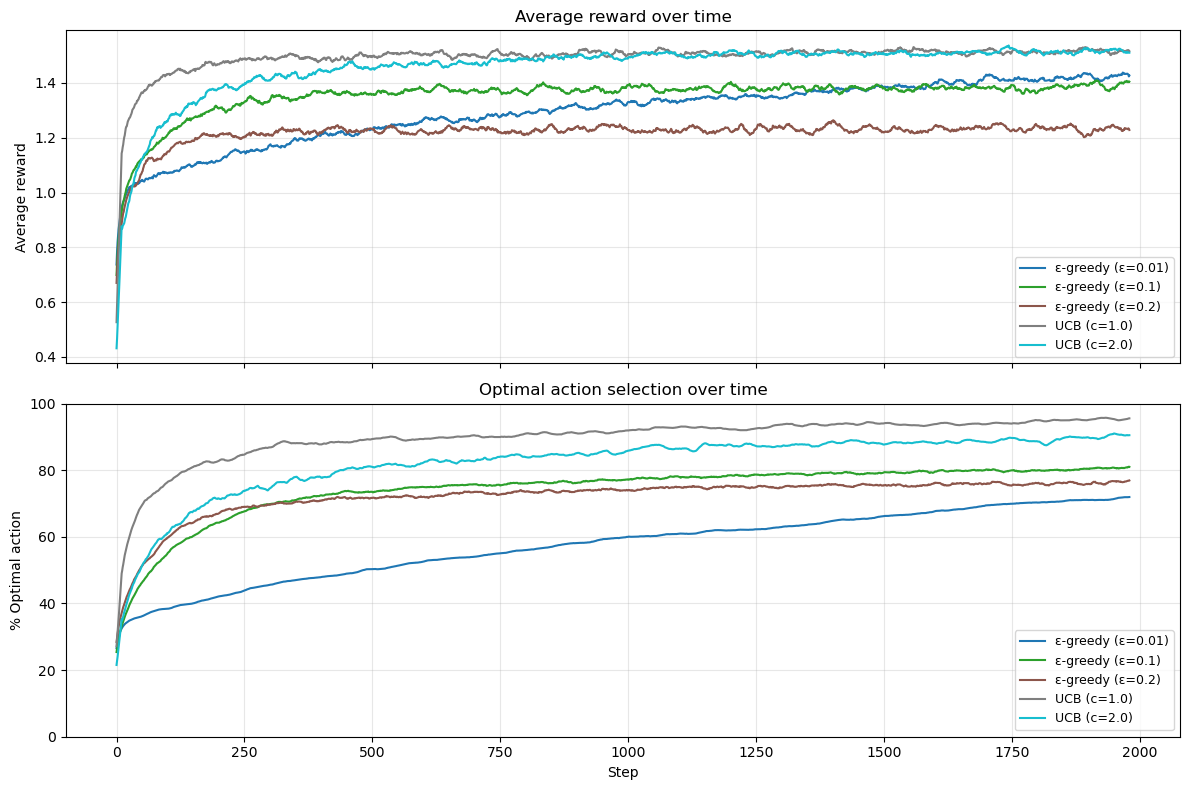

In [4]:
from src.plotting import plot_comparison

# Plot average reward and optimal action percentage
plot_comparison(results, panels=["reward", "optimal_pct"], smoothing=20, save_path="img/bandit_comparison.png")
print("\nPlot saved to bandit_comparison.png")

# Lab Assignment - Part 2

Explore Gymnasium’s standard environments (FrozenLake-v1, Taxi-v3). Write code to inspect their observation and action spaces (discrete vs. continuous, dimensions, bounds). Implement a random policy agent and measure its performance. Document how the MDP tuple (S, A, R, P, γ) maps to Gymnasium’s API. Your implementation should be modular with separate agent classes that interact with environments through the standard interface.